In [1]:
from transformers import AutoProcessor, AutoModelForCausalLM
import torch


model_path = "model/florence2"
model = (
    AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.float16,
        trust_remote_code=True,
    )
    .cuda()
    .eval()
)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

print("\n========== TOKENIZER CHECK ==========")

print("<text> id:", processor.tokenizer.convert_tokens_to_ids("<text>"))
print("<character> id:", processor.tokenizer.convert_tokens_to_ids("<character>"))
print("<panel> id:", processor.tokenizer.convert_tokens_to_ids("<panel>"))
print("<tail> id:", processor.tokenizer.convert_tokens_to_ids("<tail>"))

print("\nFirst 200 vocab tokens:")
vocab_keys = list(processor.tokenizer.get_vocab().keys())
print(vocab_keys[:200])

print("====================================\n")

/home/zaln/miniconda3/envs/magiv3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zaln/miniconda3/envs/magiv3/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warn


========== TOKENIZER CHECK ==========
<text> id: 51290
<character> id: 51291
<panel> id: 51289
<tail> id: 51292

First 200 vocab tokens:
['icons', 'Ġcartridges', 'Ġyard', 'ĠMartial', 'Ġopener', 'acks', 'If', 'ĠFur', 'ĠJackson', 'Ġcurve', 'Ġsegment', 'Ġpop', 'xt', 'Contract', 'orical', 'Ġerupted', 'Ġsubstance', 'ĠLR', 'oplan', 'Ġdisembark', 'Ġviolated', 'Ġnozzle', 'Remove', 'ãħĭãħĭ', 'Ġarrows', 'ĠMicha', 'pers', 'Ġminer', 'Ġfledgling', '<loc_642>', 'Ġreleases', 'ĠWealth', 'ĠMur', 'ĠCapitals', 'Ġinstit', 'atel', 'Ġauxiliary', 'Ġtyped', 'Ġpsy', 'Bra', 'Ġcosmetic', 'ĠUR', 'Ġbathrooms', 'ĠAnders', 'Ġcomposed', 'Ġ207', 'aroo', 'pped', 'Ġsubsidiary', 'Ġmem', 'æĢ', 'cro', 'Ġ7000', 'Ġdeletion', 'ĠXin', 'ĠUnderstand', 'ĠSahara', 'ĠDorothy', 'Ġpraises', 'omew', 'Ġsupportive', 'Ġbead', 'Ġtestify', 'Ġperformance', 'ĠSlav', 'Know', 'Ġcyclists', 'Ġfundamentalist', 'ĠHol', 'Ġsubcontract', 'Then', '<loc_918>', 'Ġparagraph', '<loc_809>', 'Ġclock', 'ĠBath', 'ger', 'oulder', 'aca', 'lon', 'Ġ][', 'Ġeval',

In [2]:
from PIL import Image
import numpy as np

filename = "1_en.jpg"

image = Image.open("input/" + filename).convert("RGB")

In [3]:
from model.florence2.utils import visualise_single_image_prediction

result = model.predict_detections_and_associations([image], processor)[0]
result["dialog_confidences"] = [1.0] * len(result["texts"])

visualise_single_image_prediction(np.array(image), result, "output/" + filename)
print(result.keys())
print(result)

/home/zaln/miniconda3/envs/magiv3/lib/python3.10/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(



========== GENERATED TEXT ==========
<panel><panel><panel><panel><panel><panel><panel><text><text><text><text><text><text><text><text><text><text><text><text><text><text><text><text><character><character><character><character><character><character><character><character><character><character><tail><tail><tail><tail><tail><tail><tail><tail><tail><tail><tail><tail>


=== [DEBUG] 真实的 Token 序列 ===
['<s>', '<loc_411>', '<loc_0>', '<loc_951>', '<loc_345>', '<panel>', '<loc_0>', '<loc_51>', '<loc_409>', '<loc_343>', '<panel>', '<loc_464>', '<loc_358>', '<loc_949>', '<loc_601>', '<panel>', '<loc_0>', '<loc_358>', '<loc_466>', '<loc_599>', '<panel>', '<loc_649>', '<loc_609>', '<loc_948>', '<loc_999>', '<panel>', '<loc_385>', '<loc_609>', '<loc_649>', '<loc_943>', '<panel>', '<loc_0>', '<loc_603>', '<loc_393>', '<loc_999>', '<panel>', '<loc_838>', '<loc_47>', '<loc_926>', '<loc_109>', '<text>', '<loc_729>', '<loc_89>', '<loc_845>', '<loc_152>', '<text>', '<loc_445>', '<loc_83>', '<loc_627>', '<l

In [6]:
import json
from ocr_utils import order_ocr_results, draw_boxes_and_print_texts

res_unordered = json.load(open("ocr_results_unordered.json", "r"))
res_ordered = order_ocr_results(res_unordered, result["panels"])
with open("ocr_results_ordered.json", "w", encoding="utf-8") as f:
    json.dump(res_ordered, f, ensure_ascii=False)

draw_boxes_and_print_texts(res_ordered, "output")


Image: input/1_en.jpg
[1] BUTIOPTION(Z)IS NOTTHINKVIABLE.THE HARMWOULD JUSTTURNINTOVIOLENCE FROMCURSE-USERS.FROM SPIRITS
[2] CAUSE A LOT MORE《PHYSICAL-GIFTED》TO BE BORN?WOULDN'T THATPEOPLE LIKE TSURUGI
[3] JUST AS EASILYBE EVIL.PEOPLE COULDTURNOUT TOAND THOSE
[4] POSSESSES ANTHOSE DON'TAPPEAR UNLESSAMOUNTOFCURSEDSOMEONE ORIGINALLYEXTREMELYPOTENTIALTO TECHNIQUE ORENERGY.
[5] WHICHMEANSOPTION(1):REMOVE CURSEDENERGY FROMWE SHOULDPROCEED WITHJAPANESE ANDSIMURIANS.
[6] RIGHT?FORWARD INTHAT WAY,soWE'LL MOVE
[7] SPIRITSPROBABLYCURSEDWON'TBEBORN FROMSIMURIANS.
[8] CREATE FRICTIONENERGY ONLY FROMEARTHLINGS,IT'LLLATER.IF WE TAKE CURSED
[9] YEAH,THAT'STRUE...
[10] TALKINGAFTERTHIS FAR...WELL THEN...
[11] EXCUSE ME.I'M MARURU.
[12] TO DO?WHAT DOYOU THINKABOUT WHATMARURU,WE'RE ABOUT
[13] IT'SATONE-MENT...
[14] CAUSEDTROUBLEWE'VEFOR EARTH.

Saved to: output/1_en.jpg


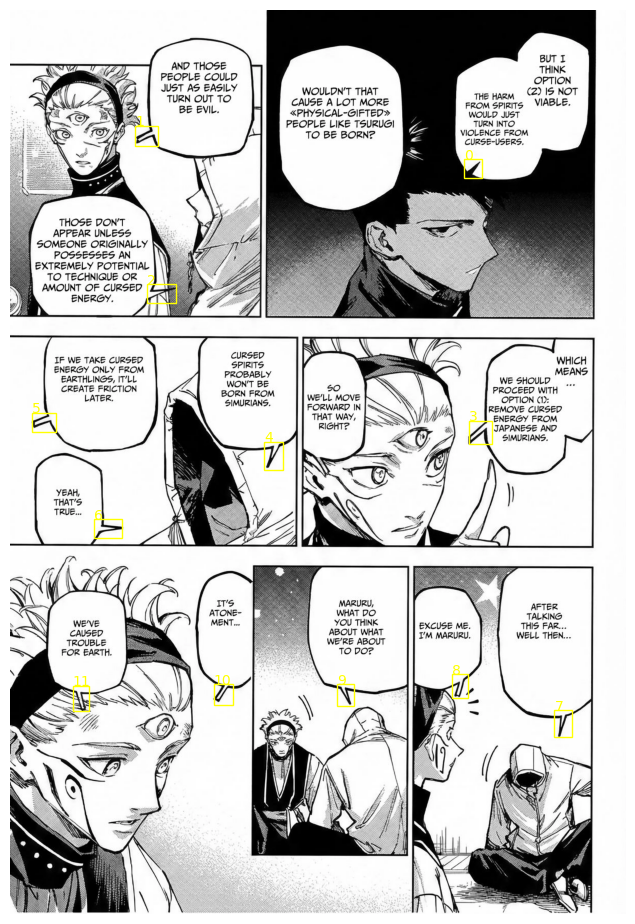

In [9]:
# 可视化tail

import matplotlib.pyplot as plt

image_np = np.array(image)

h, w = image_np.shape[:2]
if h > w:
    fig, ax = plt.subplots(figsize=(8, 8 * h / w))
else:
    fig, ax = plt.subplots(figsize=(8 * w / h, 8))

ax.imshow(image_np)

for i, bbox in enumerate(result["tails"]):
    x1, y1, x2, y2 = bbox
    width = x2 - x1
    height = y2 - y1

    rect = plt.Rectangle(
        (x1, y1),
        width,
        height,
        linewidth=1,
        edgecolor='yellow',
        facecolor='none'
    )
    ax.add_patch(rect)

    # 可选：显示 index
    ax.text(x1, y1, str(i), color='yellow', fontsize=10)

ax.axis("off")
plt.show()